In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt


try:
    import seaborn as sns
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install seaborn
    import seaborn as sns

df = pd.read_csv("../data/processed/crop_clean.csv")
df.head()

df = pd.read_csv("../data/processed/crop_clean.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


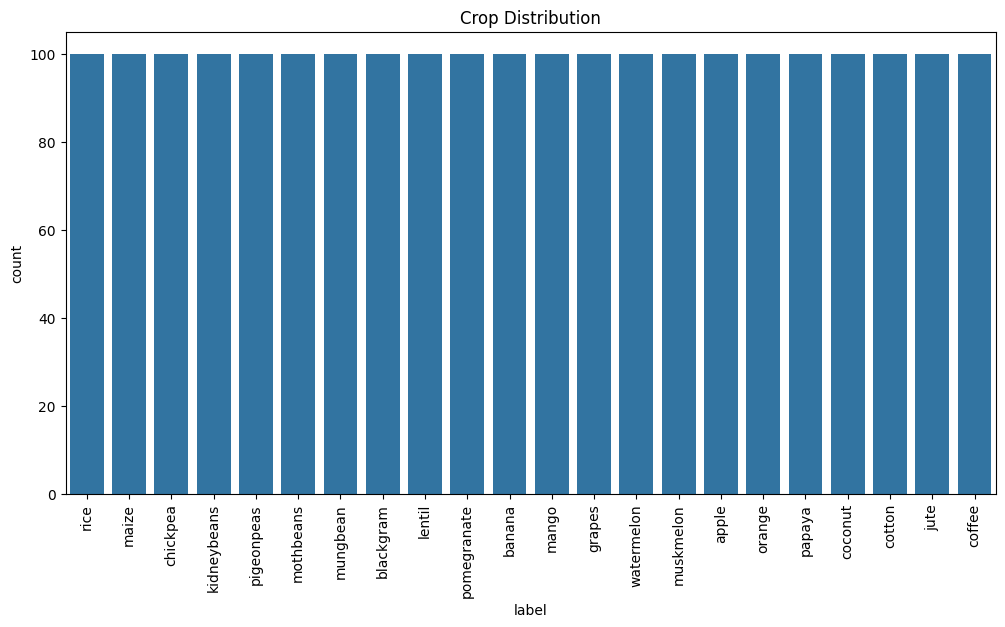

In [36]:
plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.savefig("../visuals/crop_distribution.png")
plt.show()

In [14]:
plt.savefig("../visuals/histogram_distribution.png")

<Figure size 640x480 with 0 Axes>

## Observation
The dataset is balanced, with each crop category containing approximately equal observations.
This is beneficial for classification model training.

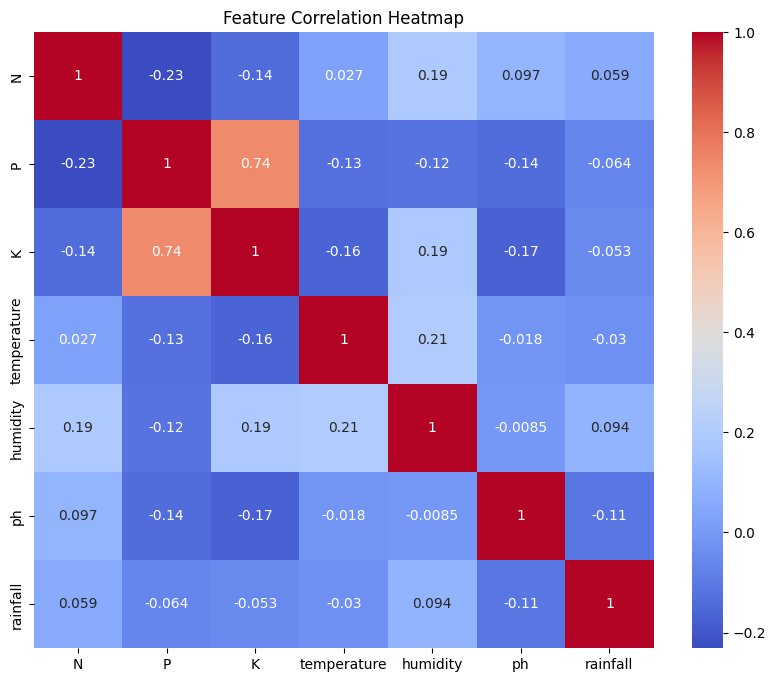

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop("label", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig("../visuals/feature_correlation_heatmap.png")
plt.show()

## Observation
The heatmap shows relationships among numerical features such as rainfall, humidity, and temperature. This helps identify correlated features useful for prediction.
(Phosphorus and Potassium show strong positive correlation (0.74), while most other features exhibit weak correlations, indicating relative feature independence.)

- Nitrogen (N) shows weak or no significant correlation with most other features (mostly light blue cells). It acts as a relatively independent variable.
- Phosphorus (P) and Potassium (K) are strongly positively correlated (0.74). These two nutrients tend to rise and fall together in the soil. This is agriculturally logical, as soils rich in one macronutrient are often rich in the other.
- Important note: This high correlation indicates multicollinearity. Using both features in a model may introduce redundancy, and one of them might be dropped or combined during feature engineering.
- Temperature and Humidity show a moderate positive correlation (0.21). This aligns with physical expectations — warmer conditions are often associated with higher humidity levels.
- Rainfall, pH, and most other pairs exhibit very weak or near-zero correlations (light blue/white cells). This is a positive sign, as these features provide unique, independent information to the model.

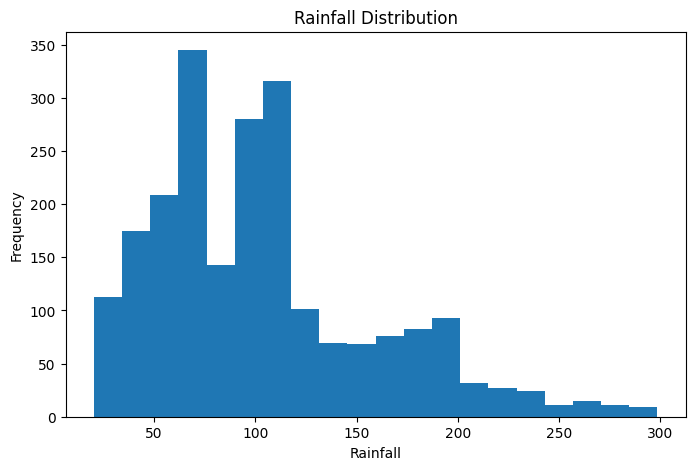

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["rainfall"], bins=20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.savefig("../visuals/rainfall_distribution.png")
plt.show()

## Observation Rainfall Distribution
- The rainfall distribution is **right-skewed** (long tail on the right) with visible **bimodal behavior (two peaks).**
- Most of the data lies in the **low-to-moderate rainfall range** (approximately 50–150 mm). A second smaller group appears in the **high rainfall zone (200–300 mm).**
- **Interpretation**: This dataset contains samples from both normal rainfall areas and high-rainfall regions. Crops like rice, jute, and sugarcane would correspond to the high-rainfall group, while many other crops thrive in the more common moderate rainfall zone.

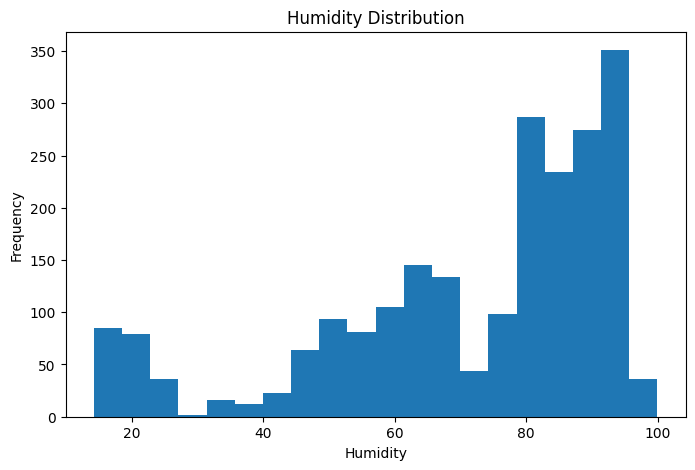

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df["humidity"], bins=20)
plt.title("Humidity Distribution")
plt.xlabel("Humidity")
plt.ylabel("Frequency")
plt.savefig("../visuals/humidity_distribution.png")
plt.show()

## Observation Rainfall Distribution

The humidity distribution is **bimodal**, showing two clear groups:

- A smaller peak at **low humidity** (around 15–25%).
- A very large, dominant peak at **high humidity** (85–100%), which contains the majority of the data.

There is a visible dip in the moderate humidity range (especially around 75–80%), with fewer samples in the middle values.

**Interpretation**: This suggests the dataset contains two different types of climates — drier regions and highly humid regions. Very few samples fall in the moderate humidity zone. This makes **humidity a strong discriminating feature** for distinguishing between different crop types in the machine learning model.

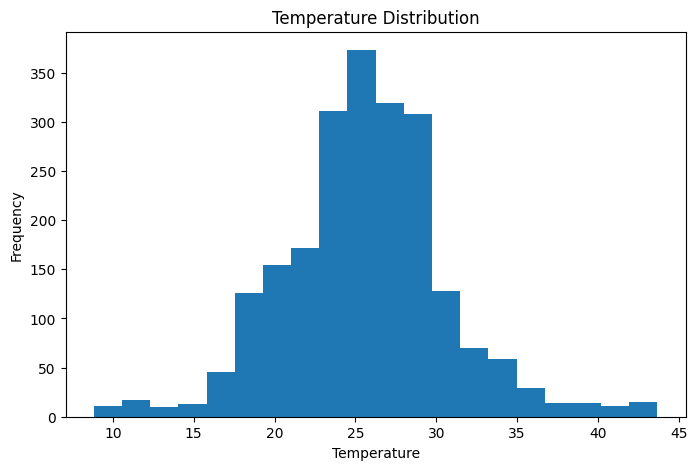

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df["temperature"], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.savefig("../visuals/temperature_distribution.png")
plt.show()

## Observation temperature Distribution
The temperature distribution is approximately **bell-shaped (normal distribution), centered around 25–30°C.**

- Majority of samples fall between 20°C and 35°C.
- Thin tails extend down to ~10°C and up to ~45°C.

**Interpretation**: Most crops in this dataset grow under moderate tropical or subtropical temperatures. The few extreme values likely represent crops like cotton or jute (high temperature) and apple/grapes (lower temperature tolerance).

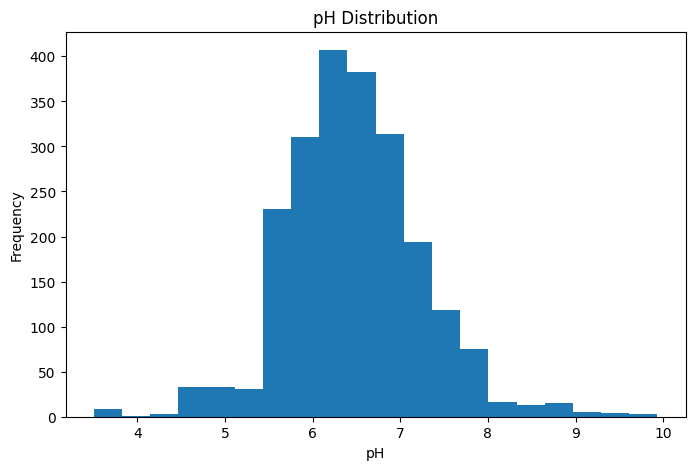

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["ph"], bins=20)
plt.title("pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.savefig("../visuals/ph_distribution.png")
plt.show()

## Observation pH Distribution

The pH distribution is bimodal with a dominant peak between **6.0–7.0** and a smaller peak around 5.0.

- Most soils are slightly acidic to neutral.
- Very few samples above pH 8.0 (alkaline soils).

**Interpretation**: The dataset is dominated by soils suitable for most common crops (ideal pH range is usually 5.5–7.5). The smaller acidic cluster (pH ~5) may represent specific acid-loving crops.

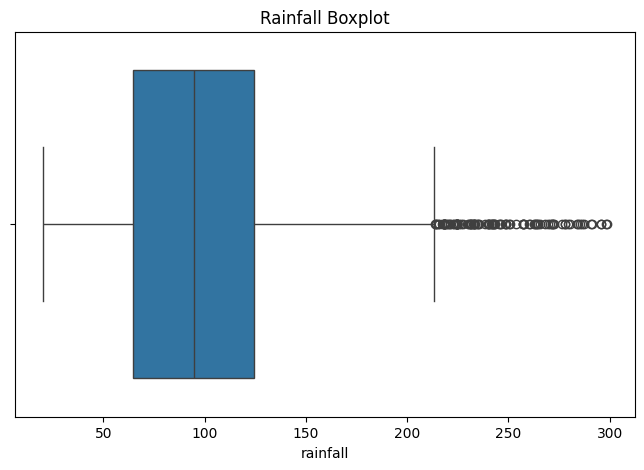

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["rainfall"])
plt.title("Rainfall Boxplot")
plt.savefig("../visuals/rainfall_boxplot.png")
plt.show()

## Observation Rainfall BoxPlot Distribution

The rainfall boxplot is heavily right-skewed.

- The box (IQR) lies between approximately 70–140 mm, with the median around 105 mm.
- The upper whisker extends to about 200 mm.
- A large cluster of outliers appears from 210 mm to 300 mm.

**Interpretation**: Most crops in the dataset require moderate rainfall. However, a significant group of high-rainfall crops (such as rice, jute, or sugarcane) creates the long right tail and outliers. This confirms the bimodal pattern seen in the histogram and highlights rainfall as an important feature for separating moderate and high-rainfall crops.

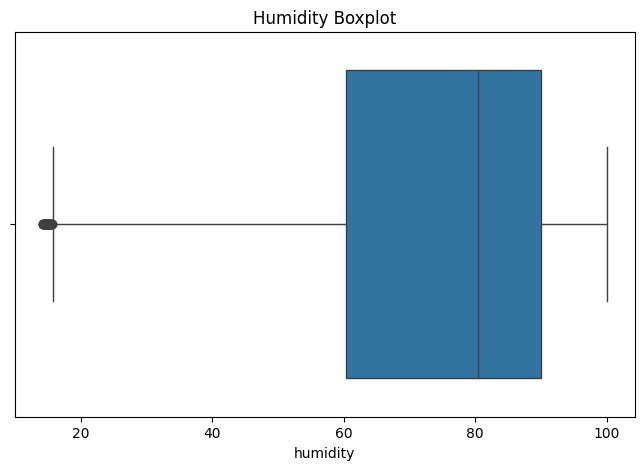

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["humidity"])
plt.title("Humidity Boxplot")
plt.savefig("../visuals/humidity_boxplot.png")
plt.show()

## Observation Humidity BoxPlot Distribution

The humidity boxplot shows high variability with a wide box.

- One clear low outlier exists around 15–18%.
- The main box (IQR) spans from roughly 65 to 90.
- The median is around 78–82.
- The upper whisker reaches near 100.

**Interpretation**: Humidity varies widely across crops. While the majority of samples are in the high humidity range (65–100%), the presence of a low outlier and wide spread indicates two climate types — dry and highly humid. This makes humidity one of the strongest discriminating features for the machine learning model.

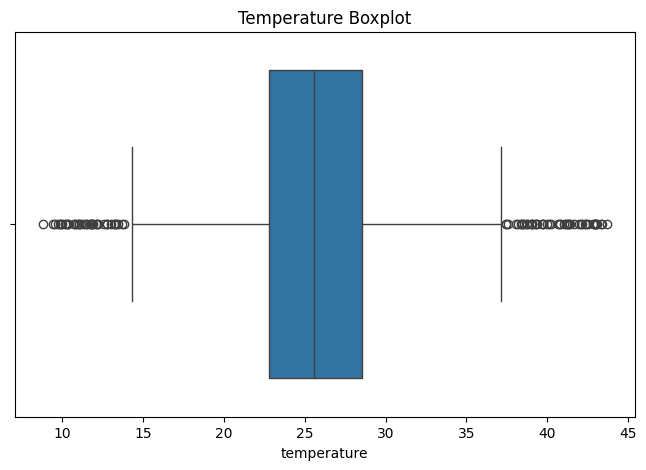

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["temperature"])
plt.title("Temperature Boxplot")
plt.savefig("../visuals/temperature_boxplot.png")
plt.show()

## Observation Temperature BoxPlot Distribution
The temperature boxplot is relatively symmetric and narrow.

- The box (IQR) ranges from approximately 23–29°C.
- The median is around 26–27°C.
- Whiskers extend from about 12–15°C to 38–40°C.
- Outliers are present on both lower (<15°C) and upper (>40°C) ends.

**Interpretation**: Most crops grow comfortably within a moderate temperature band of 23–29°C. The narrow box suggests temperature is consistent across many samples. The outliers represent specialized crops adapted to hotter (e.g., cotton, maize) or cooler climates (e.g., apple, grapes). This is one of the most well-behaved features in the dataset.

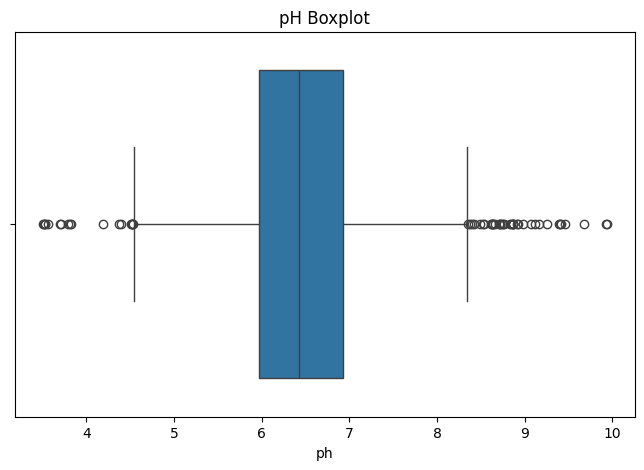

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["ph"])
plt.title("pH Boxplot")
plt.savefig("../visuals/ph_boxplot.png")
plt.show()

## Observation pH BoxPlot Distribution

The pH boxplot has a narrow IQR, indicating low variability.

- The box (IQR) spans from 6.0 to 7.0.
- The median is very close to 6.5.
- Lower whisker extends to around 5.0, upper whisker to 8.0–8.5.
- Outliers exist on both ends (below 5.0 and above 9.0).

**Interpretation**: The majority of soils in the dataset fall in the ideal slightly acidic to neutral range (6.0–7.0), which is suitable for most crops. The outliers represent rare cases of very acidic or alkaline soils for specialized crops. Overall, pH values are well-concentrated in the agriculturally favorable zone.

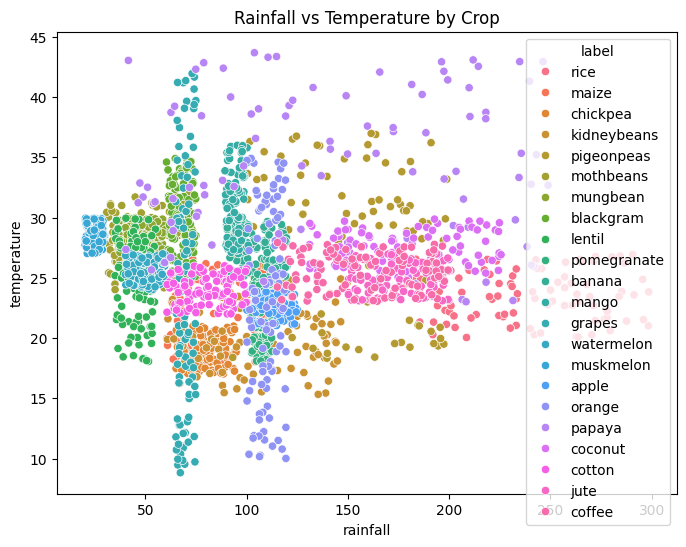

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="rainfall", y="temperature", hue="label", data=df)
plt.title("Rainfall vs Temperature by Crop")
plt.savefig("../visuals/rainfall_vs_temperature.png")
plt.show()

### Observation Scatterplot 

- **Distinct Clusters (Good Separability)**:
  - **Apple and Grapes**: Clearly separated in the **low temperature + low rainfall** zone (bottom-left).
  - **Coconut**: Occupies a unique high rainfall + high temperature area.
  - **Rice, Jute, and Coffee**: Form a high-rainfall group on the right side of the chart.
  - **Cotton**: Tends toward higher temperature regions.

- **Main Dense Cluster**:
  Most crops are concentrated in the **low-to-moderate rainfall** (50–120 mm) and **moderate temperature** (20–30°C) region. This confirms earlier findings from histograms and boxplots — the majority of crops in this dataset do not require extreme conditions.

- **Significant Overlap**:
  In the central moderate zone (roughly 30–100 mm rainfall and 20–28°C), many crops (such as chickpea, lentil, mungbean, pigeonpea, kidney beans, etc.) overlap heavily. It is difficult to separate these crops using only rainfall and temperature.

#### ML Takeaways:

- Rainfall and Temperature together provide **moderate discriminatory power**. They can easily identify extreme crops (apple, coconut, coffee, rice, etc.), but struggle with the large overlapping group in the moderate climate zone.
- This overlap explains why we need the other features (**N, P, K, humidity, pH**) to achieve high classification accuracy.
- The plot supports the strength of ensemble models like **Random Forest**, which can consider all 7 features simultaneously to resolve these overlaps.

**Conclusion**: While rainfall and temperature alone cannot perfectly separate all 22 crops, they capture important climate differences and form a strong foundation when combined with soil nutrients and pH.

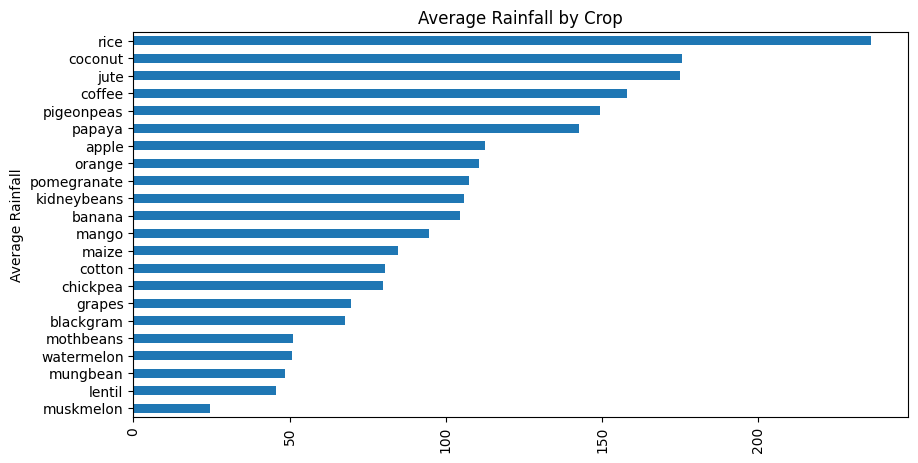

In [23]:
# Average rainfall by crop
df.groupby("label")["rainfall"].mean().sort_values(ascending=True).plot(kind='barh', figsize=(10,5))
plt.title("Average Rainfall by Crop")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=90)
plt.savefig("../visuals/average_rainfall_by_crop.png")
plt.show()

In [46]:
#average rainfall by crop
df.groupby("label")["rainfall"].mean().sort_values(ascending=False)


label
rice           236.181114
coconut        175.686646
jute           174.792798
coffee         158.066295
pigeonpeas     149.457564
papaya         142.627839
apple          112.654779
orange         110.474969
pomegranate    107.528442
kidneybeans    105.919778
banana         104.626980
mango           94.704515
maize           84.766988
cotton          80.398043
chickpea        80.058977
grapes          69.611829
blackgram       67.884151
mothbeans       51.198487
watermelon      50.786219
mungbean        48.403601
lentil          45.680454
muskmelon       24.689952
Name: rainfall, dtype: float64

###  Average Rainfall Requirement by Crop

The bar chart shows clear differences in rainfall needs across crops:

- **Highest Rainfall Crops**: 
  - **Rice** (highest ~236 mm)
  - Coconut, Jute, and Coffee (170–175 mm)

- **Moderate Rainfall Crops**: Papaya, Pigeonpeas, Orange, Apple, etc.

- **Low Rainfall Crops**: 
  - Muskmelon, Lentil, Mungbean, Watermelon (lowest)

**Interpretation**: Rice, coconut, and jute are **high-rainfall crops**, while many pulses (lentil, mungbean, chickpea) and melons prefer lower rainfall. This confirms the right-skewed distribution seen earlier.

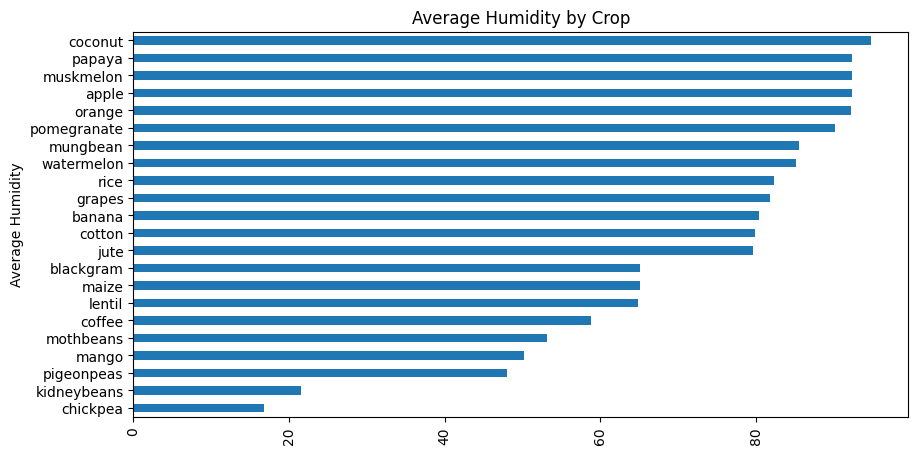

In [22]:
#average humidity by crop
df.groupby("label")["humidity"].mean().sort_values(ascending=True).plot(kind='barh', figsize=(10,5))
plt.title("Average Humidity by Crop")   
plt.ylabel("Average Humidity")
plt.xticks(rotation=90)
plt.savefig("../visuals/average_humidity_by_crop.png")
plt.show()

###  Average Humidity Requirement by Crop

- **Highest Humidity Crops**:
  - **Coconut** (highest)
  - Papaya, Muskmelon, Apple, Orange, Pomegranate

- **Moderate to High Humidity**: Most fruit crops and rice.

- **Low Humidity Crops**:
  - **Chickpea** (lowest), Kidneybeans, Pigeonpeas

**Interpretation**: Tropical fruit crops (coconut, papaya, muskmelon) prefer very high humidity, while many pulse crops (chickpea, kidney beans) can tolerate drier conditions. Humidity is a strong differentiating feature.

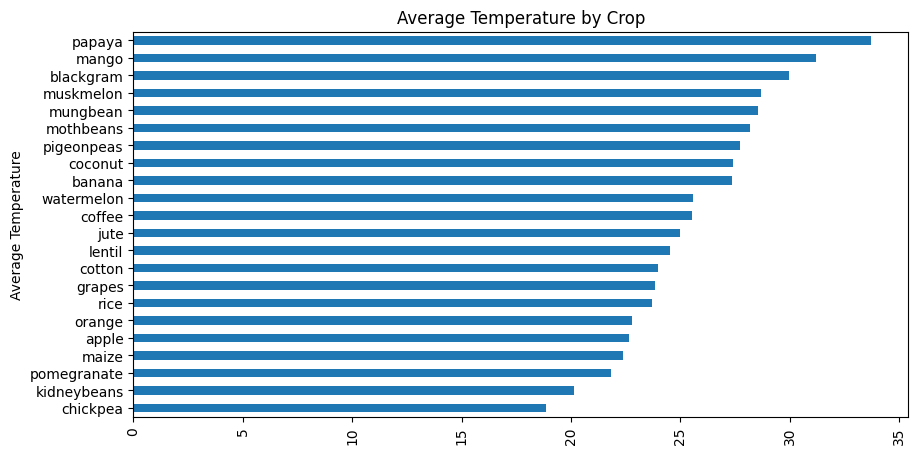

In [21]:
#average temperature by crop
df.groupby("label")["temperature"].mean().sort_values(ascending=True).plot(kind='barh', figsize=(10,5))
plt.title("Average Temperature by Crop")
plt.ylabel("Average Temperature")
plt.xticks(rotation=90) #i want to rotate the x-axis labels for better readability
plt.savefig("../visuals/average_temperature_by_crop.png")
plt.show()

In [47]:
# average temperature by crop
df.groupby("label")["temperature"].mean().sort_values(ascending=False)

label
papaya         33.723859
mango          31.208770
blackgram      29.973340
muskmelon      28.663066
mungbean       28.525775
mothbeans      28.194920
pigeonpeas     27.741762
coconut        27.409892
banana         27.376798
watermelon     25.591767
coffee         25.540477
jute           24.958376
lentil         24.509052
cotton         23.988958
grapes         23.849575
rice           23.689332
orange         22.765725
apple          22.630942
maize          22.389204
pomegranate    21.837842
kidneybeans    20.115085
chickpea       18.872847
Name: temperature, dtype: float64

###  Average Temperature Requirement by Crop

- **Highest Temperature Crops**:
  - **Papaya** (~33.7°C)
  - Mango, Blackgram, Muskmelon, Mungbean

- **Moderate Temperature Crops** (most common):
  - Banana, Coconut, Pigeonpeas, Coffee, Jute

- **Lowest Temperature Crops**:
  - **Chickpea** (~18.9°C)
  - Kidneybeans, Pomegranate, Maize, Apple

**Interpretation**: Papaya and mango are warm-season crops, while chickpea and apple prefer cooler climates. Temperature shows good variation across crops.

In [39]:
df.groupby("label")["N"].mean().sort_values(ascending=False)

label
cotton         117.77
coffee         101.20
muskmelon      100.32
banana         100.23
watermelon      99.42
rice            79.89
jute            78.40
maize           77.76
papaya          49.88
chickpea        40.09
blackgram       40.02
grapes          23.18
coconut         21.98
mothbeans       21.44
mungbean        20.99
apple           20.80
kidneybeans     20.75
pigeonpeas      20.73
mango           20.07
orange          19.58
pomegranate     18.87
lentil          18.77
Name: N, dtype: float64

In [40]:
df.groupby("label")["P"].mean().sort_values(ascending=False)

label
apple          134.22
grapes         132.53
banana          82.01
lentil          68.36
chickpea        67.79
pigeonpeas      67.73
kidneybeans     67.54
blackgram       67.47
papaya          59.05
maize           48.44
mothbeans       48.01
rice            47.58
mungbean        47.28
jute            46.86
cotton          46.24
coffee          28.74
mango           27.18
pomegranate     18.75
muskmelon       17.72
watermelon      17.00
coconut         16.93
orange          16.55
Name: P, dtype: float64

In [41]:
df.groupby("label")["K"].mean().sort_values(ascending=False)

label
grapes         200.11
apple          199.89
chickpea        79.92
watermelon      50.22
muskmelon       50.08
banana          50.05
papaya          50.04
pomegranate     40.21
jute            39.99
rice            39.87
coconut         30.59
coffee          29.94
mango           29.92
pigeonpeas      20.29
mothbeans       20.23
kidneybeans     20.05
mungbean        19.87
maize           19.79
cotton          19.56
lentil          19.41
blackgram       19.24
orange          10.01
Name: K, dtype: float64

### NPK Requirements by Crop

#### **Nitrogen (N) Requirements**
- **Very High N**: Cotton (117.77), Coffee (101.20), Muskmelon (100.32), Banana (100.23), Watermelon (99.42)
- **High N**: Rice (79.89), Jute (78.40), Maize (77.76)
- **Low N**: Most pulses and fruits (Apple, Grapes, Lentil, etc.)

#### **Phosphorus (P) Requirements**
- **Very High P**: **Apple (134.22)**, **Grapes (132.53)**
- **Moderate P**: Banana (82), Lentil & Chickpea (~68)
- **Low P**: Most tropical crops (Coconut, Muskmelon, Watermelon, Orange)

#### **Potassium (K) Requirements**
- **Extremely High K**: **Grapes (200.11)**, **Apple (199.89)**
- **Moderate K**: Chickpea (79.92), Watermelon & Muskmelon (~50)
- **Low K**: Most other crops (< 40)

### **Key Insights on NPK Relationships**

- **Apple and Grapes** are unique — they require exceptionally **high Phosphorus and Potassium**.
- **Cotton and Coffee** are heavy **Nitrogen feeders**.
- **Banana** needs high amounts of **all three** nutrients (N, P, K).
- Many **pulse crops** (chickpea, kidneybeans, pigeonpeas, mungbean) have relatively **balanced but moderate** NPK needs.
- **Rice** requires high Nitrogen and moderate rainfall.
- **Coconut** needs high rainfall + high humidity but relatively low NPK.

**ML Takeaway**: N, P, and K are highly informative features. Certain crops (Apple, Grapes, Cotton, Rice) have very distinct nutrient signatures, which helps the model classify them accurately.